# Notebook de depuración visual para FiftyOne

Objetivo: iterar rápidamente cómo se verán en FiftyOne las imágenes generadas/comprimidas y los overlays/campos asociados antes de tocar el loader final.

## 1) Instalar y cargar dependencias

Instalamos/validamos dependencias y dejamos imports comunes para depuración repetible.

In [1]:
# Si falta alguna dependencia en el kernel, descomenta:
# %pip install -q fiftyone pillow pandas matplotlib

import os
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import fiftyone as fo
from fiftyone import ViewField as F
%matplotlib inline
%matplotlib notebook

# Añadir raíz del proyecto para imports locales
project_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.pose_uncertainty.evaluation.storage import load_deep_analysis
from src.pose_uncertainty.visualization.fiftyone_loader import _packet_to_samples, _CACHE_SUBDIR

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 10
print(f"Project root: {project_root}")

c:\Users\Santiago estudio\AppData\Local\pypoetry\Cache\virtualenvs\robust-pose-tta-HTcMH1tG-py3.11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: C:\Users\Santiago estudio\Desktop\TFG_Informatica\robust-pose-tta


## 2) Definir rutas y seleccionar imagen de ejemplo (generada/comprimida)

In [2]:
data_dir = project_root / "outputs" / "2026-02-11" / "12-40-42"
cache_dir = data_dir / _CACHE_SUBDIR
cache_dir.mkdir(parents=True, exist_ok=True)

pkl_files = sorted(data_dir.glob("*.pkl.gz"))
assert len(pkl_files) > 0, f"No hay .pkl.gz en {data_dir}"

# Elegimos automáticamente un paquete que genere varias slices
example_pkl = None
packet = None
for p in pkl_files:
    pkt = load_deep_analysis(str(p))
    tmp_samples = _packet_to_samples(pkt, cache_dir, fo)
    if len(tmp_samples) >= 3:
        example_pkl = p
        packet = pkt
        break

if example_pkl is None:
    example_pkl = pkl_files[0]
    packet = load_deep_analysis(str(example_pkl))

print("Paquete ejemplo:", example_pkl.name)
print("image_id:", packet.get("meta", {}).get("image_id"))
print("tta_data:", len(packet.get("tta_data", [])))

Paquete ejemplo: Edge_Cases_105912.pkl.gz
image_id: 105912
tta_data: 2


## 3) Descubrir automáticamente todas las imágenes visibles en FiftyOne

Primero generamos las slices de ejemplo con el mismo código del loader; luego listamos todas las imágenes creadas para ese paquete.

In [3]:
samples = _packet_to_samples(packet, cache_dir, fo)
assert len(samples) > 0, "No se generaron samples"

image_paths = [Path(s.filepath) for s in samples]
for p in image_paths:
    assert p.exists(), f"No existe: {p}"

print(f"Slices generadas: {len(samples)}")
for s in samples:
    print(f"- {s['group'].name:20s} -> {Path(s.filepath).name}")

Slices generadas: 6
- original             -> Edge_Cases_105912_original.jpg
- mix_analysis         -> Edge_Cases_105912_mix_analysis.jpg
- tta_0_image          -> Edge_Cases_105912_tta0_image.jpg
- tta_0_heatmaps       -> Edge_Cases_105912_tta0_heatmaps.jpg
- tta_1_image          -> Edge_Cases_105912_tta1_image.jpg
- tta_1_heatmaps       -> Edge_Cases_105912_tta1_heatmaps.jpg


## 4) Construir el dataset de depuración con metadatos completos

In [4]:
dataset_name = "TFG_Debug_FiftyOne_Notebook"
if fo.dataset_exists(dataset_name):
    fo.delete_dataset(dataset_name)

dataset = fo.Dataset(dataset_name)
dataset.add_group_field("group", default="original")
dataset.add_samples(samples)

# metadatos de imagen en todas las slices del grupo
slice_names = sorted({s["group"].name for s in samples})
for s in dataset.select_group_slices(slice_names):
    p = Path(s.filepath)
    with Image.open(p) as im:
        w, h = im.size
        mode = im.mode
    s["width"] = int(w)
    s["height"] = int(h)
    s["channels"] = int(3 if mode in ("RGB", "P") else 1)
    s["file_size_bytes"] = int(p.stat().st_size)
    s["file_mtime"] = datetime.fromtimestamp(p.stat().st_mtime)
    s.save()

print(dataset)
print("Num groups:", len(dataset))
print("Num slices:", len(dataset.select_group_slices(slice_names)))

 100% |█████████████████████| 6/6 [358.8ms elapsed, 0s remaining, 16.7 samples/s]     
Name:        TFG_Debug_FiftyOne_Notebook
Media type:  group
Group slice: original
Num groups:  1
Persistent:  False
Tags:        []
Sample fields:
    id:                   fiftyone.core.fields.ObjectIdField
    filepath:             fiftyone.core.fields.StringField
    tags:                 fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:             fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.Metadata)
    created_at:           fiftyone.core.fields.DateTimeField
    last_modified_at:     fiftyone.core.fields.DateTimeField
    group:                fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.groups.Group)
    image_id:             fiftyone.core.fields.IntField
    oks_delta:            fiftyone.core.fields.FloatField
    nll:                  fiftyone.core.fields.FloatField
    entropy:              fiftyone.core.fields.FloatField
    

## 5) Agregar campos visibles en FiftyOne (tags, split, compresión, dimensiones, tamaño)

In [5]:
slice_names = sorted({s["group"].name for s in samples})
all_slices_for_update = dataset.select_group_slices(slice_names)

for s in all_slices_for_update:
    slice_name = s["group"].name
    is_heatmap = ("heatmap" in slice_name) or (slice_name == "mix_analysis")

    s.tags = list(set((s.tags or []) + ["debug", "notebook", slice_name]))
    s["split"] = "debug"
    s["source"] = "deep_profiling_packet"
    s["version"] = "v1_grouped_debug"
    s["compression"] = "jpeg"
    s["compression_quality"] = 95
    s["batch_name"] = data_dir.name
    s["status"] = "ok"
    s["is_heatmap_slice"] = bool(is_heatmap)
    s.save()

print("Campos añadidos a todas las slices")
print("Field schema:", sorted(dataset.get_field_schema().keys()))

Campos añadidos a todas las slices
Field schema: ['batch_name', 'channels', 'compression', 'compression_quality', 'covariance_volume', 'created_at', 'entropy', 'file_mtime', 'file_size_bytes', 'filepath', 'gmm_ellipses', 'ground_truth', 'group', 'height', 'id', 'image_id', 'is_heatmap_slice', 'last_modified_at', 'mc_samples', 'metadata', 'nll', 'oks_base', 'oks_delta', 'oks_ours', 'prediction_base', 'prediction_ours', 'source', 'split', 'status', 'tags', 'tta_index', 'tta_name', 'uncertainty_ellipses', 'version', 'width']


In [6]:
# Tabla rápida para validar metadatos por slice
# (robusto a estados viejos de variables/view)
if "samples" in globals() and len(samples) > 0:
    slice_names_local = sorted({s["group"].name for s in samples})
else:
    slice_names_local = ["original"]

flat_view_local = dataset.select_group_slices(slice_names_local)

rows = []
for s in flat_view_local:
    rows.append({
        "slice": s["group"].name,
        "w": s["width"] if s.has_field("width") else None,
        "h": s["height"] if s.has_field("height") else None,
        "size_kb": round((s["file_size_bytes"] if s.has_field("file_size_bytes") else 0) / 1024, 1),
        "heatmap": s["is_heatmap_slice"] if s.has_field("is_heatmap_slice") else None,
    })

df_meta = pd.DataFrame(rows).sort_values(["slice"]).reset_index(drop=True)
df_meta

,slice,w,h,size_kb,heatmap
0,mix_analysis,1200,1500,109.5,True
1,original,500,375,84.8,False
2,tta_0_heatmaps,1200,1500,92.6,True
3,tta_0_image,500,375,84.8,False
4,tta_1_heatmaps,1200,1500,110.7,True
5,tta_1_image,500,375,82.4,False


## 6) Adjuntar anotaciones de prueba para previsualizar "todo lo visible" en la App

In [7]:
# Añadimos etiquetas demo solo cuando no existan, para validar render del panel lateral
# (robusto a estados viejos de variables/view)
if "samples" in globals() and len(samples) > 0:
    slice_names_local = sorted({s["group"].name for s in samples})
else:
    slice_names_local = ["original"]

flat_view_local = dataset.select_group_slices(slice_names_local)

def maybe_add_debug_labels(sample):
    if not sample.has_field("debug_class"):
        sample["debug_class"] = fo.Classification(label="ok", confidence=0.99)

    if not sample.has_field("debug_box"):
        sample["debug_box"] = fo.Detections(detections=[
            fo.Detection(label="roi", bounding_box=[0.1, 0.1, 0.8, 0.8], confidence=0.8)
        ])

    if not sample.has_field("debug_poly"):
        sample["debug_poly"] = fo.Polylines(polylines=[
            fo.Polyline(points=[[(0.1, 0.1), (0.9, 0.1), (0.9, 0.9), (0.1, 0.9)]], closed=True, filled=False, label="frame")
        ])

    if not sample.has_field("debug_kps"):
        sample["debug_kps"] = fo.Keypoints(keypoints=[
            fo.Keypoint(points=[(0.2, 0.2), (0.8, 0.2), (0.5, 0.8)], label="triad")
        ])

    sample.save()

for s in flat_view_local:
    maybe_add_debug_labels(s)

print("Anotaciones debug añadidas en todas las slices")

Anotaciones debug añadidas en todas las slices


## 7) Crear vistas de depuración (filtros, orden, selección de campos)

In [8]:
slice_names = sorted({s["group"].name for s in samples})
flat_view = dataset.select_group_slices(slice_names)

view_all = flat_view.sort_by("file_size_bytes", reverse=True)
view_heatmaps = flat_view.match(F("is_heatmap_slice") == True).sort_by("file_size_bytes", reverse=True)
view_original = flat_view.match(F("group.name") == "original")

print("group_count (len dataset):", len(dataset))
print("slice_count (len flat_view):", len(flat_view))
print("view_heatmaps:", len(view_heatmaps))
print("view_original:", len(view_original))

flat_view.select_fields([
    "group", "image_id", "width", "height", "file_size_bytes",
    "is_heatmap_slice", "split", "status", "tags"
]).head(3)

group_count (len dataset): 1
slice_count (len flat_view): 6
view_heatmaps: 3
view_original: 1


[<SampleView: {
     'id': '698dcccea1830854664c8f9c',
     'media_type': 'image',
     'filepath': 'C:\\Users\\Santiago estudio\\Desktop\\TFG_Informatica\\robust-pose-tta\\outputs\\2026-02-11\\12-40-42\\fiftyone_cache\\Edge_Cases_105912_original.jpg',
     'tags': ['original', 'debug', 'notebook'],
     'metadata': None,
     'created_at': datetime.datetime(2026, 2, 12, 12, 51, 26, 93000),
     'last_modified_at': datetime.datetime(2026, 2, 12, 12, 51, 27, 722000),
     'group': <Group: {'id': '698dcccca1830854664c8f48', 'name': 'original'}>,
     'image_id': 105912,
     'width': 500,
     'height': 375,
     'file_size_bytes': 86816,
     'split': 'debug',
     'status': 'ok',
     'is_heatmap_slice': False,
 }>,
 <SampleView: {
     'id': '698dcccea1830854664c8f9d',
     'media_type': 'image',
     'filepath': 'C:\\Users\\Santiago estudio\\Desktop\\TFG_Informatica\\robust-pose-tta\\outputs\\2026-02-11\\12-40-42\\fiftyone_cache\\Edge_Cases_105912_mix_analysis.jpg',
     'tags': ['mi

## Vista previa local (matplotlib) de todo lo que se verá en FiftyOne

Mostramos todas las imágenes/slices del grupo y un resumen de overlays por slice.

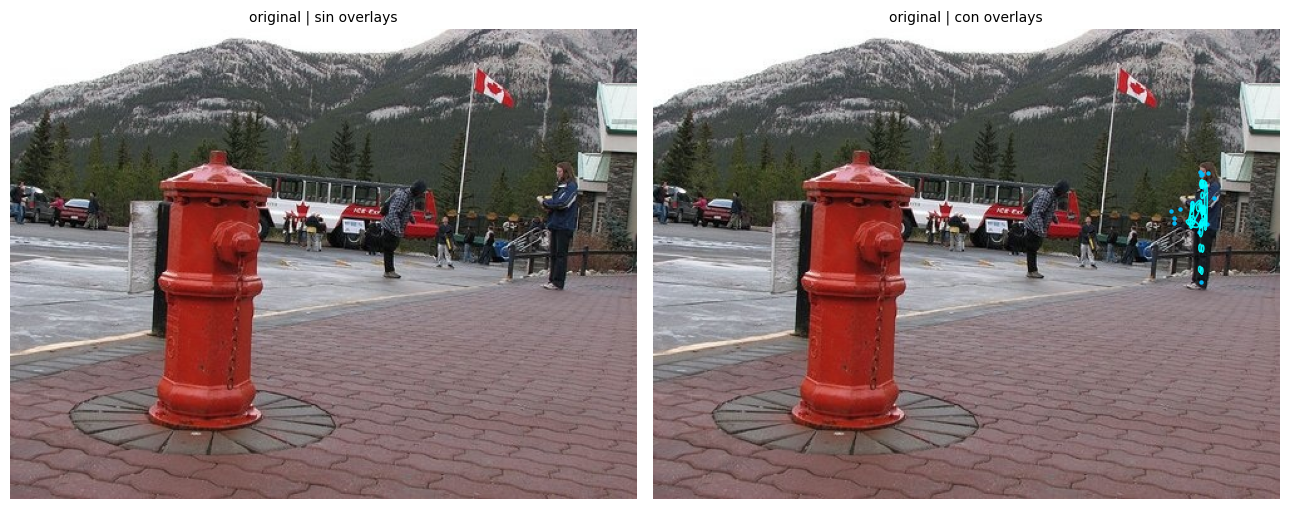

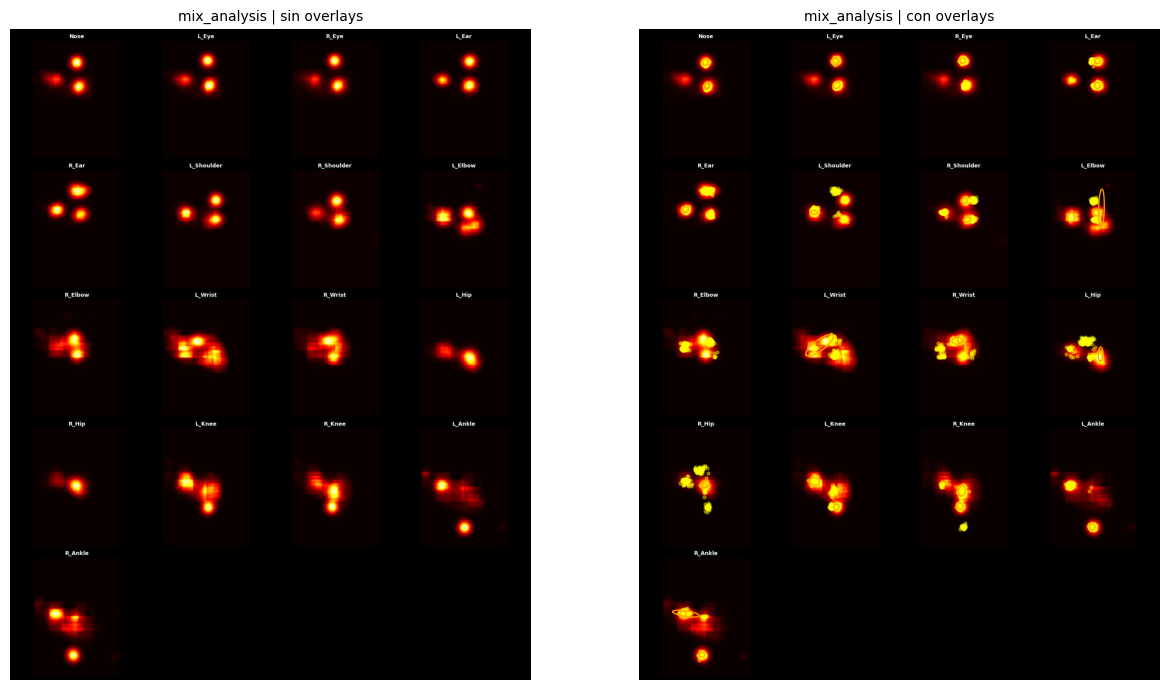

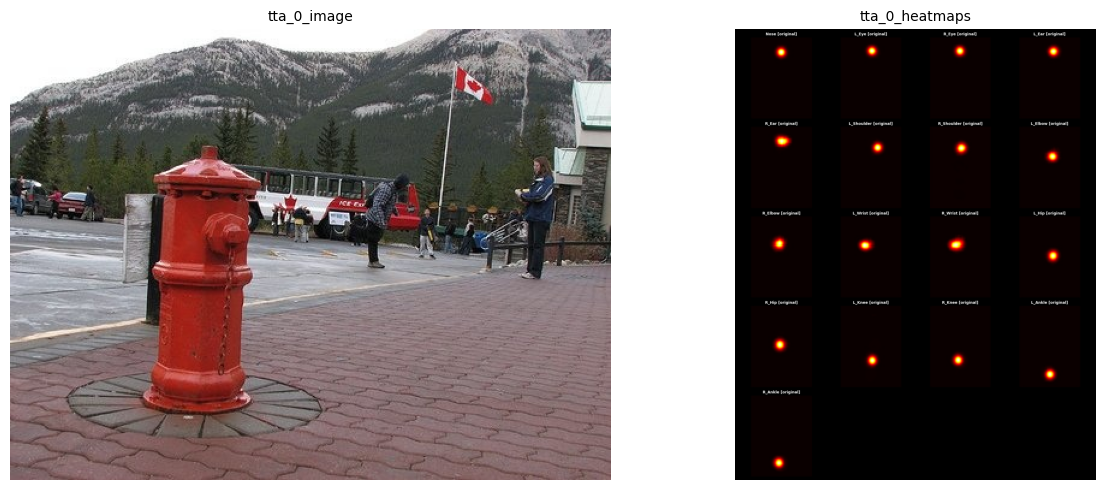

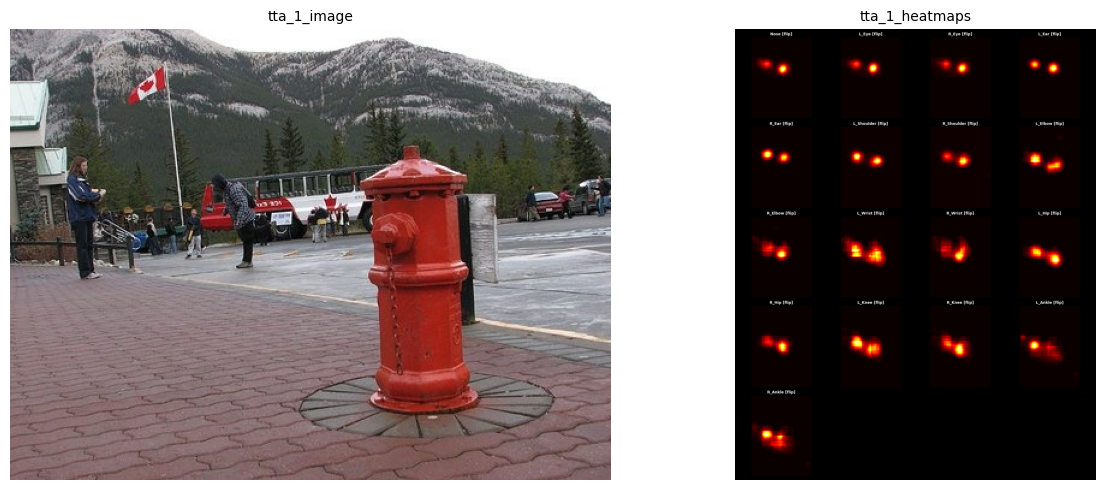

,bloque,slice,overlays_aplicados,shape
0,mix_analysis,mix_analysis,"mc_samples, gmm_ellipses",1200x1500
1,original,original,"prediction_ours, uncertainty_ellipses",500x375
2,tta_pair,tta_0_heatmaps,,1200x1500
3,tta_pair,tta_0_image,,500x375
4,tta_pair,tta_1_heatmaps,,1200x1500
5,tta_pair,tta_1_image,,500x375


In [9]:
# Vista detallada por separado (dentro del notebook)
# 1) Imagen original: overlays configurables
# 2) Heatmap promedio: overlays configurables
# 3) TTA: imagen y heatmap lado a lado por cada TTA

# ----------------------------
# Configuración de overlays
# ----------------------------
# ORIGINAL
ORIG_SHOW_GT = False
ORIG_SHOW_PRED_BASE = False
ORIG_SHOW_PRED_OURS = True
ORIG_SHOW_UNCERTAINTY = True

# HEATMAP PROMEDIO (mix_analysis)
MIX_SHOW_MC_SAMPLES = True
MIX_SHOW_GMM_ELLIPSES = True

# DEBUG EXTRA
SHOW_DEBUG_LABELS = False

# Garantizar vista válida aunque haya cambios de estado
if "samples" in globals() and len(samples) > 0:
    slice_names_local = sorted({s["group"].name for s in samples})
else:
    slice_names_local = sorted(dataset.distinct("group.name"))

flat_view_local = dataset.select_group_slices(slice_names_local)
samples_by_slice = {s["group"].name: s for s in flat_view_local}


def _draw_keypoint_like(ax, obj, w, h, color="lime", size=18, alpha=0.9):
    if obj is None:
        return

    # fo.Keypoint -> obj.points
    if hasattr(obj, "points") and obj.points is not None:
        pts = obj.points
        xs = [float(p[0]) * w for p in pts]
        ys = [float(p[1]) * h for p in pts]
        ax.scatter(xs, ys, c=color, s=size, alpha=alpha)

    # fo.Keypoints -> obj.keypoints
    if hasattr(obj, "keypoints") and obj.keypoints is not None:
        for kp in obj.keypoints:
            if kp is None or not hasattr(kp, "points") or kp.points is None:
                continue
            xs = [float(p[0]) * w for p in kp.points]
            ys = [float(p[1]) * h for p in kp.points]
            ax.scatter(xs, ys, c=color, s=size, alpha=alpha)


def _draw_polylines(ax, obj, w, h, color="cyan", lw=1.2, alpha=0.9):
    if obj is None or not hasattr(obj, "polylines") or obj.polylines is None:
        return

    for poly in obj.polylines:
        if poly is None or not hasattr(poly, "points") or poly.points is None:
            continue
        for contour in poly.points:
            if contour is None or len(contour) == 0:
                continue
            xs = [float(p[0]) * w for p in contour]
            ys = [float(p[1]) * h for p in contour]
            ax.plot(xs, ys, color=color, linewidth=lw, alpha=alpha)


def _draw_detections(ax, obj, w, h, color="yellow", lw=1.5, alpha=0.9):
    if obj is None or not hasattr(obj, "detections") or obj.detections is None:
        return

    for det in obj.detections:
        if det is None or not hasattr(det, "bounding_box") or det.bounding_box is None:
            continue
        x, y, bw, bh = det.bounding_box
        x *= w
        y *= h
        bw *= w
        bh *= h
        rect = plt.Rectangle((x, y), bw, bh, fill=False, edgecolor=color, linewidth=lw, alpha=alpha)
        ax.add_patch(rect)


def _apply_debug_overlays(ax, sample, w, h, present):
    if not SHOW_DEBUG_LABELS:
        return
    if sample.has_field("debug_kps") and sample["debug_kps"] is not None:
        _draw_keypoint_like(ax, sample["debug_kps"], w, h, color="magenta", size=5)
        present.append("debug_kps")
    if sample.has_field("debug_poly") and sample["debug_poly"] is not None:
        _draw_polylines(ax, sample["debug_poly"], w, h, color="white", lw=1.0)
        present.append("debug_poly")
    if sample.has_field("debug_box") and sample["debug_box"] is not None:
        _draw_detections(ax, sample["debug_box"], w, h, color="yellow", lw=1.3)
        present.append("debug_box")


preview_rows = []

# ==========================================================
# 1) Imagen original (sin/con overlays)
# ==========================================================
orig = samples_by_slice.get("original")
if orig is not None:
    img = np.array(Image.open(orig.filepath).convert("RGB"))
    h, w = img.shape[:2]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax0, ax1 = axes

    ax0.imshow(img)
    ax0.set_title("original | sin overlays")
    ax0.axis("off")

    ax1.imshow(img)
    ax1.set_title("original | con overlays")
    ax1.axis("off")

    present = []
    if ORIG_SHOW_GT and orig.has_field("ground_truth") and orig["ground_truth"] is not None:
        _draw_keypoint_like(ax1, orig["ground_truth"], w, h, color="lime", size=5)
        present.append("ground_truth")

    if ORIG_SHOW_PRED_BASE and orig.has_field("prediction_base") and orig["prediction_base"] is not None:
        _draw_keypoint_like(ax1, orig["prediction_base"], w, h, color="red", size=5)
        present.append("prediction_base")

    if ORIG_SHOW_PRED_OURS and orig.has_field("prediction_ours") and orig["prediction_ours"] is not None:
        _draw_keypoint_like(ax1, orig["prediction_ours"], w, h, color="deepskyblue", size=5)
        present.append("prediction_ours")

    if ORIG_SHOW_UNCERTAINTY and orig.has_field("uncertainty_ellipses") and orig["uncertainty_ellipses"] is not None:
        _draw_polylines(ax1, orig["uncertainty_ellipses"], w, h, color="cyan", lw=1.2)
        present.append("uncertainty_ellipses")

    _apply_debug_overlays(ax1, orig, w, h, present)

    plt.tight_layout()
    display(fig)
    plt.close(fig)

    preview_rows.append({
        "bloque": "original",
        "slice": "original",
        "overlays_aplicados": ", ".join(present),
        "shape": f"{w}x{h}",
    })

# ==========================================================
# 2) Heatmap promedio mix_analysis (sin/con overlays)
# ==========================================================
mix = samples_by_slice.get("mix_analysis")
if mix is not None:
    img = np.array(Image.open(mix.filepath).convert("RGB"))
    h, w = img.shape[:2]

    fig, axes = plt.subplots(1, 2, figsize=(13, 7))
    ax0, ax1 = axes

    ax0.imshow(img)
    ax0.set_title("mix_analysis | sin overlays")
    ax0.axis("off")

    ax1.imshow(img)
    ax1.set_title("mix_analysis | con overlays")
    ax1.axis("off")

    present = []
    if MIX_SHOW_MC_SAMPLES and mix.has_field("mc_samples") and mix["mc_samples"] is not None:
        _draw_keypoint_like(ax1, mix["mc_samples"], w, h, color="yellow", size=4, alpha=0.35)
        present.append("mc_samples")

    if MIX_SHOW_GMM_ELLIPSES and mix.has_field("gmm_ellipses") and mix["gmm_ellipses"] is not None:
        _draw_polylines(ax1, mix["gmm_ellipses"], w, h, color="orange", lw=1.0)
        present.append("gmm_ellipses")

    _apply_debug_overlays(ax1, mix, w, h, present)

    plt.tight_layout()
    display(fig)
    plt.close(fig)

    preview_rows.append({
        "bloque": "mix_analysis",
        "slice": "mix_analysis",
        "overlays_aplicados": ", ".join(present),
        "shape": f"{w}x{h}",
    })

# ==========================================================
# 3) Imágenes TTA y heatmaps al lado
# ==========================================================
tta_image_slices = sorted([k for k in samples_by_slice if k.startswith("tta_") and k.endswith("_image")])

for img_slice in tta_image_slices:
    idx = img_slice.replace("tta_", "").replace("_image", "")
    hm_slice = f"tta_{idx}_heatmaps"

    s_img = samples_by_slice.get(img_slice)
    s_hm = samples_by_slice.get(hm_slice)

    if s_img is None and s_hm is None:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ax0, ax1 = axes

    if s_img is not None:
        arr = np.array(Image.open(s_img.filepath).convert("RGB"))
        ax0.imshow(arr)
        ax0.set_title(f"{img_slice}")
        ax0.axis("off")
        h0, w0 = arr.shape[:2]
        preview_rows.append({
            "bloque": "tta_pair",
            "slice": img_slice,
            "overlays_aplicados": "",
            "shape": f"{w0}x{h0}",
        })
    else:
        ax0.text(0.5, 0.5, "No disponible", ha="center", va="center")
        ax0.set_title(img_slice)
        ax0.axis("off")

    if s_hm is not None:
        arr = np.array(Image.open(s_hm.filepath).convert("RGB"))
        ax1.imshow(arr)
        ax1.set_title(f"{hm_slice}")
        ax1.axis("off")
        h1, w1 = arr.shape[:2]
        preview_rows.append({
            "bloque": "tta_pair",
            "slice": hm_slice,
            "overlays_aplicados": "",
            "shape": f"{w1}x{h1}",
        })
    else:
        ax1.text(0.5, 0.5, "No disponible", ha="center", va="center")
        ax1.set_title(hm_slice)
        ax1.axis("off")

    plt.tight_layout()
    display(fig)
    plt.close(fig)

# Tabla resumen
preview_df = pd.DataFrame(preview_rows).sort_values(["bloque", "slice"]).reset_index(drop=True)
preview_df

## 8) Lanzar sesión de FiftyOne y ajustar paneles de la App

In [10]:
# Ejecuta esta celda para abrir la App dentro de VS Code / navegador
# Puedes cambiar la vista inicial aquí:
initial_view = view_all

session = fo.launch_app(dataset, view=initial_view, auto=False)
print("Sesión lanzada. Puedes filtrar por tags, group.name y overlays en la barra lateral.")
session

Connected to FiftyOne on port 5151 at localhost.
If you are not connecting to a remote session, you may need to start a new session and specify a port
Session launched. Run `session.show()` to open the App in a cell output.
Sesión lanzada. Puedes filtrar por tags, group.name y overlays en la barra lateral.


Dataset:          TFG_Debug_FiftyOne_Notebook
Media type:       group
Num samples:      6
Selected samples: 0
Selected labels:  0
Session URL:      http://localhost:5151/
View stages:
    1. SelectGroupSlices(slices=['mix_analysis', 'original', 'tta_0_heatmaps', ...], media_type=None, flat=True)
    2. SortBy(field_or_expr='file_size_bytes', reverse=True, create_index=False)

## 9) Validar ejecución del notebook con checks rápidos (smoke tests)

In [11]:
assert len(dataset) > 0, "Dataset vacío"
assert dataset.first() is not None, "No hay primer sample"

expected_core_fields = {"group", "image_id", "file_size_bytes", "is_heatmap_slice", "status"}
actual_fields = set(dataset.get_field_schema().keys())
missing = expected_core_fields - actual_fields
assert not missing, f"Faltan campos: {missing}"

assert len(flat_view) >= 3, "flat_view debería tener varias slices"
assert len(view_original) >= 1, "No hay slice original"
assert len(view_heatmaps) >= 1, "No hay slices heatmap"

print("[OK] Smoke tests superados")
print("Dataset:", dataset_name)
print("Num groups:", len(dataset))
print("Num slices flat_view:", len(flat_view))
print("Slices únicas:", sorted({s['group'].name for s in flat_view}))

[OK] Smoke tests superados
Dataset: TFG_Debug_FiftyOne_Notebook
Num groups: 1
Num slices flat_view: 6
Slices únicas: ['mix_analysis', 'original', 'tta_0_heatmaps', 'tta_0_image', 'tta_1_heatmaps', 'tta_1_image']
